Homework week 7 - How many Solar farms are in each State?

In [ ]:
import geopandas as gpd

SolarPV = gpd.read_file("solarPV.geojson") #Data from April 2026

States= gpd.read_file("./us_state/tl_2025_us_state.shp")

In [ ]:
SolarPV.columns #check columns of both 

Index(['FID', 'Id', 'case_id', 'multi_poly', 'eia_id', 'p_state', 'p_county',
       'ylat', 'xlong', 'p_area', 'p_img_date', 'p_dig_conf', 'p_name',
       'p_year', 'p_pwr_reg', 'p_tech_pri', 'p_tech_sec', 'p_sys_type',
       'p_axis', 'p_azimuth', 'p_tilt', 'p_battery', 'p_cap_ac', 'p_cap_dc',
       'p_type', 'p_agrivolt', 'p_comm', 'p_zscore', 'geometry'],
      dtype='str')

In [5]:
States.columns

Index(['REGION', 'DIVISION', 'STATEFP', 'STATENS', 'GEOID', 'GEOIDFQ',
       'STUSPS', 'NAME', 'LSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER',
       'INTPTLAT', 'INTPTLON', 'geometry'],
      dtype='str')

In [ ]:
States.crs #check crs of both 

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [6]:
SolarPV.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
Solar = SolarPV.to_crs(States.crs) #make them both in the same crs
Solar.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

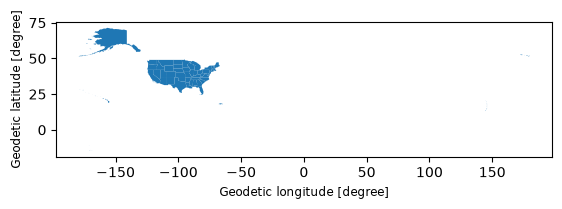

In [18]:
States.plot() #check the data 

<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

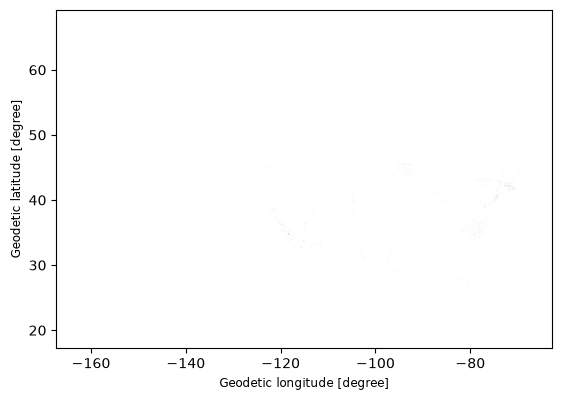

In [ ]:
SolarPV.plot() #PROBLEM

something went wrong with my solar_pv.plot() so i will check the data again below 

In [21]:
SolarPV.geometry

0       POLYGON ((-97.6768 35.47837, -97.67701 35.4783...
1       POLYGON ((-78.97948 43.01831, -78.97944 43.015...
2       POLYGON ((-90.00022 39.40521, -90.00142 39.405...
3       POLYGON ((-74.04066 42.3727, -74.04092 42.3727...
4       POLYGON ((-89.84004 42.38148, -89.84265 42.381...
                              ...                        
6606    MULTIPOLYGON (((-84.36765 31.87947, -84.36968 ...
6607    POLYGON ((-94.82276 45.42902, -94.82324 45.429...
6608    POLYGON ((-74.6577 40.57289, -74.65769 40.5717...
6609    POLYGON ((-88.12932 38.72079, -88.12909 38.720...
6610    MULTIPOLYGON (((-108.66059 45.88386, -108.6624...
Name: geometry, Length: 6611, dtype: geometry

In [23]:
SolarPV.geometry.isna().sum()

np.int64(0)

In [24]:
SolarPV.total_bounds

array([-162.55713535,   19.65529486,  -67.45975666,   66.83988864])

In [ ]:
SolarPV.geom_type.value_counts() #this right here is a problem because they are not points but it is okay, i can still visualize them in a .plot() together rather than seperatley 

Polygon         3529
MultiPolygon    3082
Name: count, dtype: int64

Spatial Join for States & Solar PV data

In [ ]:
Solar_states = gpd.sjoin(Solar,States,predicate="within") 
Solar_states.columns #check the join worked between the two tables 

Index(['FID', 'Id', 'case_id', 'multi_poly', 'eia_id', 'p_state', 'p_county',
       'ylat', 'xlong', 'p_area', 'p_img_date', 'p_dig_conf', 'p_name',
       'p_year', 'p_pwr_reg', 'p_tech_pri', 'p_tech_sec', 'p_sys_type',
       'p_axis', 'p_azimuth', 'p_tilt', 'p_battery', 'p_cap_ac', 'p_cap_dc',
       'p_type', 'p_agrivolt', 'p_comm', 'p_zscore', 'geometry', 'index_right',
       'REGION', 'DIVISION', 'STATEFP', 'STATENS', 'GEOID', 'GEOIDFQ',
       'STUSPS', 'NAME', 'LSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER',
       'INTPTLAT', 'INTPTLON'],
      dtype='str')

In [ ]:
Solar_count = Solar_states.groupby("NAME").size() #group by state name & count them 
Solar_count = Solar_count.reset_index(name="solar_pv_count") #make the column name solar_pv_count 

The outcome of Solar_count, is a table that shows how many Solar PV facilities are in each U.S State

In [16]:
Solar_count

,NAME,solar_pv_count
0,Alabama,11
1,Alaska,2
2,Arizona,110
3,Arkansas,63
4,California,893
5,Colorado,156
6,Connecticut,82
7,Delaware,15
8,District of Columbia,14
9,Florida,202


(24.0, 50.0)

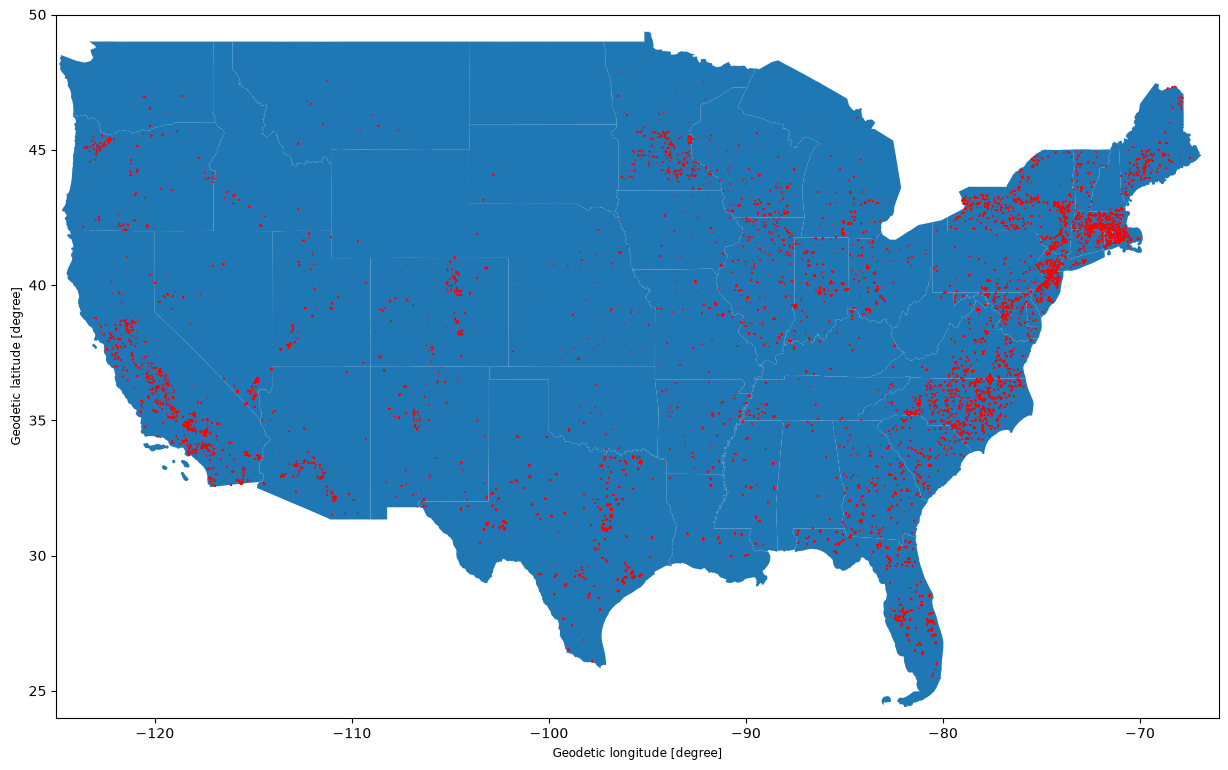

In [31]:
ax = States.plot(figsize=(15, 10))

SolarPV.plot(
    ax=ax,
    edgecolor="red"
)

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

Attibute Join, joining the state names together rather than by geometry

In [33]:
import pandas as pd

In [36]:
renewable = pd.read_csv("RenewableEnergyData.csv")

In [38]:
renewable.columns

Index(['Table P5B.  Primary energy production estimates, renewable and total energy, in trillion Btu, ranked by state, 2024',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14',
       'Unnamed: 15'],
      dtype='str')